# Himalayan GLOF Early-Warning Monitor (near-real-time)

Combines your two notebooks into one pipeline:

* **`Inference_try.ipynb`** → your trained **Keras DeepLabV3+** (`deeplabv3_50.keras`) and the preprocessing it was validated with
* **`Himalayan_GLOF_Realtime_Sliding_Window_FIXED`** → whole-belt scanning, weather / GPM / seismic context, SQLite time series

and adds what was missing for *detecting sudden events*: a per-lake baseline, drawdown/expansion anomaly tests, a Sentinel-1 radar check that works through cloud, and alert levels.

```text
STAGE 0  (once)      GLIMS glaciers + Sentinel-2 NDWI + Copernicus DEM  →  lake registry (CSV)
                     (+ your 13 Uttarakhand lakes and South Lhonak as validated seeds)

STAGE 1  (each cycle) for every lake: new Sentinel-2 scenes → 4 km chip (400×400 @10 m)
                      → SCL cloud mask → DeepLabV3+ → lake area inside the lake footprint
                      → stored in SQLite

STAGE 2  (each cycle) Sentinel-1 SAR water-area change (cloud-independent, same orbit)
                      + Open-Meteo rain/temperature + GPM IMERG + USGS earthquakes

STAGE 3  (each cycle) robust baseline (median/MAD) → drawdown / rapid-change tests
                      → GREEN / YELLOW / ORANGE / RED → console, webhook, Telegram
```

### What changed relative to your realtime notebook
| Issue in the old notebook | Fix here |
|---|---|
| Placeholder, untrained PyTorch U-Net | Your Keras DeepLabV3+ with the exact custom layers/losses |
| Percentile stretch (differs from your tested pipeline) | `INPUT_MODE="reflectance255"` = identical to `Inference_try`; percentile is optional |
| `weather["current"]` was `df.iloc[-1]` = the last **forecast** hour | Split at "now": rain totals use the past only, forecast uses the future only |
| Whole-scene NDWI + `getInfo()` over the belt every cycle | Registry built once, tiled; each cycle touches only 4 km chips |
| No cloud/shadow masking | SCL mask + per-lake "clear pixels inside footprint" gate |
| Track IDs from drifting centroids | Fixed lake registry, stable `lake_id`, `UNIQUE(lake_id, scene_id)` |
| Area change relative to *processing* time | Relative to **scene** time, robust median/MAD baseline |
| No event logic | Alert scoring, cooldowns, webhook/Telegram |

### Read this before trusting any alert
* **"Real-time" here is near-real-time.** Earth Engine's Sentinel-2 SR archive lags acquisition by roughly 1–3 days, and the satellite revisits every ~5 days (cloud permitting). Sentinel-1 helps in monsoon cloud. Neither catches an outburst *as it happens*; they flag it within days. For minutes-scale warning you need in-lake sensors.
* **Seasonal ice and snow** can look like lake drawdown in optical imagery. The notebook records a `possible_ice_cover` flag when it is freezing, but you must interpret alerts.
* The DeepLab model was only checked on 13 Uttarakhand lakes. Run the **smoke test** and the **South Lhonak replay** before you rely on it elsewhere.
* This produces *observations and anomaly flags*, not a calibrated GLOF probability.

## 0 · Setup

In [1]:
%pip -q install earthengine-api rasterio shapely pyproj scipy opencv-python-headless folium pandas requests matplotlib
# TensorFlow/Keras is preinstalled on Colab.  Locally:  pip install tensorflow

In [2]:
import os, io, sys, json, math, time, sqlite3, hashlib, zipfile, warnings
from types import SimpleNamespace
from datetime import datetime, timezone, timedelta
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import requests
import cv2
import matplotlib.pyplot as plt

import rasterio
from rasterio.io import MemoryFile
from rasterio.features import rasterize
from shapely.geometry import shape, mapping, Point
from shapely.ops import transform as shp_transform, unary_union
from pyproj import CRS, Transformer
from scipy.spatial import cKDTree

import ee

import logging
warnings.filterwarnings("ignore")
logging.getLogger("rasterio._env").setLevel(logging.ERROR)   # silences harmless GDAL ExtraSamples warning

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")
print("Colab:", IN_COLAB)

Mounted at /content/drive
Colab: True


## 1 · Configuration
Everything you are likely to tune is here. **Start small** (one or two regions) and widen once the smoke test and replay look right.

In [3]:
# ------------------------------------------------------------------ paths
GEE_PROJECT = os.getenv("GEE_PROJECT", "glof-510607")
MODEL_PATH  = Path(os.getenv("MODEL_PATH", "/content/drive/MyDrive/Codes/model/deeplabv3_50.keras"))
BASE_DIR    = Path(os.getenv("GLOF_WORK_DIR",
                  "/content/drive/MyDrive/glof_monitor" if IN_COLAB else "glof_monitor"))
QUICK_DIR   = BASE_DIR / "quicklooks"
for p in (BASE_DIR, QUICK_DIR):
    p.mkdir(parents=True, exist_ok=True)
DB_PATH       = BASE_DIR / "glof_monitor.sqlite"
REGISTRY_PATH = BASE_DIR / "lake_registry.csv"

# ------------------------------------------------------------------ where to look
# (lon_min, lat_min, lon_max, lat_max).  Coarse boxes: GLIMS + elevation + slope do the real filtering.
REGIONS = {
    "Karakoram_HinduKush": (71.0, 35.0, 77.5, 37.2),
    "Ladakh_Zanskar":      (75.5, 32.5, 79.0, 35.0),
    "Himachal_Spiti":      (76.5, 30.5, 79.0, 33.0),
    "Uttarakhand":         (78.0, 29.8, 81.2, 31.5),
    "West_Nepal":          (80.0, 28.5, 83.5, 30.6),
    "Central_Nepal":       (83.0, 27.6, 86.5, 29.5),
    "Sikkim_East_Nepal":   (86.0, 27.2, 89.0, 28.5),
    "Bhutan":              (88.7, 26.9, 92.2, 28.5),
    "Arunachal":           (92.0, 27.2, 97.5, 29.5),
}
ACTIVE_REGIONS = ["Uttarakhand", "Sikkim_East_Nepal"]   # <- widen gradually
MAX_LAKES      = 150          # monitor at most this many auto-detected lakes (largest first); seeds always kept
USE_SEED_LAKES = True

# ------------------------------------------------------------------ stage 0: lake registry
ELEV_MIN_M        = 3000      # glacial lakes in the Himalaya are rarely lower
SLOPE_MAX_DEG     = 12        # lakes are flat: removes most terrain-shadow false positives
NDWI_T            = 0.10      # (B3-B8)/(B3+B8), candidate generator only; DeepLab does the real measurement
GLACIER_BUFFER_M  = 10_000    # candidate must lie within this distance of a GLIMS glacier
LAKE_MIN_KM2, LAKE_MAX_KM2 = 0.005, 10.0
TILE_DEG          = 0.5       # registry is built tile by tile (keeps each Earth Engine call small)
CLUSTER_KM        = 1.5       # candidates closer than this share one 4 km monitoring chip
SEED_RADIUS_M     = 1000      # footprint radius for seed lakes that have no polygon

# ------------------------------------------------------------------ stage 1: optical ingest
CHIP_M, PIXEL_M, MODEL_SIZE = 4000, 10, 400      # 4 km @ 10 m = 400 x 400 = your training size
FOOTPRINT_BUFFER_M   = 300    # lake area is counted inside (registry footprint + this buffer)
MAX_SCENE_CLOUD_PCT  = 85     # loose scene-level prefilter; the real test is clear pixels *at the lake*
MIN_FOOTPRINT_VALID  = 0.80   # observation is "reliable" only if >=80% of the footprint is cloud-free
BAD_SCL              = (0, 1, 3, 8, 9, 10)       # no-data, saturated, shadow, cloud med/high, cirrus
MODEL_BANDS          = ["B8", "B4", "B3"]        # order your model was trained with
INPUT_MODE           = "reflectance255"          # identical to Inference_try. Alt: "percentile"
UNET_THRESHOLD       = 0.50                      # kept name from old notebook; applies to DeepLab output
BACKFILL_DAYS        = 90     # history gathered the first time a lake is seen (builds the baseline)
LOOKBACK_DAYS        = 20     # normal cycles re-check this window (retries failed downloads)
DOWNLOAD_BUDGET      = 200    # max chips per cycle; backlog is cleared over later cycles
EE_WORKERS, DL_WORKERS, CHUNK = 8, 4, 16
SAVE_QUICKLOOKS      = True   # PNG overlays for scenes from the last 15 days

# ------------------------------------------------------------------ stage 2: context
SAR_WINDOW_DAYS = 120      # ~10 same-orbit repeats at a 12-day cycle
SAR_WATER_DB    = -18.0       # VV threshold (dB) for open water. Heuristic, not calibrated.
SAR_MIN_COVER   = 0.90
SAR_MIN_BASELINE_IMAGES = 3   # same-orbit images needed before a SAR change is judged
SAR_MIN_REL_SIGMA = 0.10      # noise floor: at least 10% of baseline, however calm the history looks
SEISMIC_LOOKBACK_DAYS, SEISMIC_MIN_MAG = 7, 2.5
WX_BATCH = 20
ENABLE_GPM = True

# ------------------------------------------------------------------ stage 3: detection
D = SimpleNamespace(
    BASELINE_DAYS=120, MIN_HISTORY=3, MIN_LAKE_KM2=0.01,
    DRAWDOWN_PCT=30, SEVERE_DRAWDOWN_PCT=60,       # vs median baseline
    RAPID_PCT=20, RAPID_DAYS=15, MIN_Z=3.0,        # vs previous reliable scene
    SAR_DROP_PCT=40, SAR_RISE_PCT=40, SAR_MIN_Z=3.0,   # SAR needs BOTH a % change and a z-score vs its own noise
    RAIN_24H_MM=50, RAIN_72H_MM=100,
    QUAKE_MAG=4.5, QUAKE_KM=150, QUAKE_HOURS=72,
    RECENT_OPTICAL_DAYS=15, COOLDOWN_HOURS=48,
)
LEVELS = ["GREEN", "YELLOW", "ORANGE", "RED"]
NOTIFY_MIN_LEVEL = "ORANGE"

# ------------------------------------------------------------------ polling
POLL_HOURS = 6                # Sentinel-2 revisits every ~5 days; polling more often wastes quota

print("Work dir:", BASE_DIR.resolve())
print("Regions :", ACTIVE_REGIONS)

Work dir: /content/drive/MyDrive/glof_monitor
Regions : ['Uttarakhand', 'Sikkim_East_Nepal']


In [4]:
def init_earth_engine():
    try:
        ee.Initialize(project=GEE_PROJECT)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=GEE_PROJECT)
    print("Earth Engine ready:", GEE_PROJECT)

init_earth_engine()

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine ready: glof-510607


## 2 · Load your trained DeepLabV3+
Custom layers and losses are copied unchanged from `Inference_try.ipynb` so the `.keras` file deserialises exactly as it did there.

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Layer, Conv2D, BatchNormalization, ReLU

reg = tf.keras.utils.register_keras_serializable(package="glof")

@reg
class ResNetPreprocess(Layer):
    def call(self, x):
        x = tf.reverse(x, axis=[-1])
        return x - tf.constant([103.939, 116.779, 123.68], dtype=x.dtype)

@reg
class ConvBlock(Layer):
    def __init__(self, filters=256, kernel_size=3, dilation_rate=1, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.kernel_size, self.dilation_rate = filters, kernel_size, dilation_rate
        self.net = Sequential([
            Conv2D(filters, kernel_size=kernel_size, padding="same", dilation_rate=dilation_rate,
                   use_bias=False, kernel_initializer="he_normal"),
            BatchNormalization(),
            ReLU(),
        ])
    def call(self, X):
        return self.net(X)
    def get_config(self):
        return {**super().get_config(), "filters": self.filters,
                "kernel_size": self.kernel_size, "dilation_rate": self.dilation_rate}

@reg
def dice_loss(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return 1.0 - tf.reduce_mean((2.0 * inter + smooth) / (denom + smooth))

@reg
def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

@reg
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2.0 * inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}  (set MODEL_PATH)"
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model input :", model.input_shape)
print("Model output:", model.output_shape)

Model input : (None, 400, 400, 3)
Model output: (None, 400, 400, 1)


## 3 · Geometry helpers
Chips are cut on a **fixed 10 m UTM grid** (corners snapped to multiples of 10 m), so a lake covers the same pixels on every date. That makes area comparisons between dates meaningful.

In [6]:
def utm_epsg(lon, lat):
    zone = int((lon + 180) / 6) + 1
    return (32600 if lat >= 0 else 32700) + zone

def local_transformers(lat, lon):
    local = CRS.from_proj4(f"+proj=aeqd +lat_0={lat} +lon_0={lon} +datum=WGS84 +units=m")
    return (Transformer.from_crs("EPSG:4326", local, always_xy=True),
            Transformer.from_crs(local, "EPSG:4326", always_xy=True))

def disc_wgs84(lat, lon, radius_m):
    _, to_wgs = local_transformers(lat, lon)
    return shp_transform(to_wgs.transform, Point(0, 0).buffer(radius_m))

def footprint_wgs84(row):
    """Lake footprint polygon (EPSG:4326). Auto-detected lakes carry a polygon; seeds get a disc."""
    gj = row.get("footprint_geojson")
    if isinstance(gj, str) and gj.strip():
        return shape(json.loads(gj))
    return disc_wgs84(row["lat"], row["lon"], SEED_RADIUS_M)

def footprint_ee(row):
    """Footprint (+buffer) as an Earth Engine geometry, for the SAR check."""
    g = footprint_wgs84(row).simplify(1e-4)
    return ee.Geometry(mapping(g)).buffer(FOOTPRINT_BUFFER_M)

def chip_region(lat, lon, size_m=CHIP_M):
    epsg = utm_epsg(lon, lat)
    x, y = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True).transform(lon, lat)
    x, y = round(x / PIXEL_M) * PIXEL_M, round(y / PIXEL_M) * PIXEL_M
    h = size_m / 2
    region = ee.Geometry.Rectangle([x - h, y - h, x + h, y + h], proj=f"EPSG:{epsg}", geodesic=False)
    return region, epsg

def footprint_mask(row, transform, crs, out_shape):
    """Rasterise the buffered footprint onto the chip grid."""
    to_chip = Transformer.from_crs("EPSG:4326", CRS.from_wkt(crs.to_wkt()), always_xy=True)
    g = shp_transform(to_chip.transform, footprint_wgs84(row)).buffer(FOOTPRINT_BUFFER_M)
    return rasterize([(mapping(g), 1)], out_shape=out_shape, transform=transform,
                     fill=0, dtype="uint8").astype(bool)

def haversine_km_vec(lat1, lon1, lat2, lon2):
    r = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2) - np.radians(lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

def to_jsonable(o):
    if isinstance(o, dict):                    return {str(k): to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):           return [to_jsonable(v) for v in o]
    if isinstance(o, (np.floating, float)):    return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):           return int(o)
    if isinstance(o, (np.bool_,)):             return bool(o)
    if isinstance(o, (pd.Timestamp, datetime)):return o.isoformat()
    return o

def utc(dt):
    t = pd.Timestamp(dt)
    return t.tz_localize("UTC") if t.tzinfo is None else t.tz_convert("UTC")
def iso(dt): return utc(dt).isoformat()
def ee_fmt(dt): return pd.Timestamp(dt).strftime("%Y-%m-%dT%H:%M:%S")

## 4 · Stage 0 — Lake registry
Built **once** and cached to `lake_registry.csv`. A pixel becomes a lake candidate when it is: water-like in last season's cloud-masked Sentinel-2 median (Aug–Nov), above `ELEV_MIN_M`, on flat ground, and within 10 km of a GLIMS glacier. Candidates are vectorised tile by tile, then clustered so lakes that share a 4 km chip are monitored together.

Your 13 Uttarakhand lakes and **South Lhonak** (Sikkim, outburst 3–4 Oct 2023) are added as seeds. South Lhonak's coordinates are approximate — the 1 km footprint disc absorbs that, but check them against imagery.

In [7]:
SEED_LAKES = [
    ("UK_GL_01", "Kedartal",                     30.910539, 78.958097, "Uttarakhand"),
    ("UK_GL_02", "Vasudhara Tal",                30.900911, 79.754922, "Uttarakhand"),
    ("UK_GL_03", "Mabang Tal (Surya Sarovar)",   30.446003, 80.387528, "Uttarakhand"),
    ("UK_GL_04", "Pyungru Tal",                  30.408394, 80.511719, "Uttarakhand"),
    ("UK_GL_05", "Masar Tal (Bhilangna Lake)",   30.742489, 78.987669, "Uttarakhand"),
    ("UK_GL_06", "Safed Tal (Goriganga Lake)",   30.564339, 80.177542, "Uttarakhand"),
    ("UK_GL_07", "Syantyankti Lake",             30.392822, 80.532919, "Uttarakhand"),
    ("UK_GL_08", "Unnamed Lake 1",               31.151186, 79.267256, "Uttarakhand"),
    ("UK_GL_09", "Unnamed Lake 2",               30.455625, 80.515914, "Uttarakhand"),
    ("UK_GL_10", "Unnamed Lake 3 (Kuthi Yangti Lower)", 30.263953, 80.712808, "Uttarakhand"),
    ("UK_GL_11", "Unnamed Lake 4 (Kuthi Yangti Upper)", 30.372439, 80.603647, "Uttarakhand"),
    ("UK_GL_12", "NaagKund (Bhairav Kund)",     30.183364, 79.875664, "Uttarakhand"),
    ("UK_GL_13", "Saraswati Tal",                30.813242, 79.925497, "Uttarakhand"),
    # Known outburst (3-4 Oct 2023). Coordinates approximate - verify on imagery.
    ("SK_GL_01", "South Lhonak Lake (GLOF Oct 2023)", 27.9040, 88.1840, "Sikkim_East_Nepal"),
]
SEEDS_ALL = pd.DataFrame(SEED_LAKES, columns=["lake_id", "name", "lat", "lon", "region"])
SEEDS_ALL["footprint_geojson"] = None
SEEDS_ALL["area_km2"] = np.nan
SEEDS_ALL["source"] = "seed"


def s2_mask(img):
    scl = img.select("SCL")
    ok = scl.neq(1).And(scl.neq(3)).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return img.updateMask(ok)


def detect_candidates(tile_bbox, season_year):
    geom = ee.Geometry.Rectangle(list(tile_bbox), proj="EPSG:4326", geodesic=False)

    ndwi = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(geom)
            .filterDate(f"{season_year}-08-01", f"{season_year}-12-01")
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 60))
            .map(s2_mask)
            .map(lambda im: im.normalizedDifference(["B3", "B8"]).rename("ndwi"))
            .median())

    dem_col = ee.ImageCollection("COPERNICUS/DEM/GLO30").select("DEM")
    dem = dem_col.mosaic().setDefaultProjection(dem_col.first().projection())
    slope = ee.Terrain.slope(dem)

    glims = ee.FeatureCollection("GLIMS/current").filterBounds(geom.buffer(GLACIER_BUFFER_M))
    near_glacier = glims.distance(GLACIER_BUFFER_M, 100).lte(GLACIER_BUFFER_M)

    cand = (ndwi.gt(NDWI_T).And(dem.gt(ELEV_MIN_M)).And(slope.lt(SLOPE_MAX_DEG))
            .And(near_glacier).selfMask())
    cand = cand.updateMask(cand.connectedPixelCount(100, True).gte(8))

    vec = cand.reduceToVectors(geometry=geom, scale=20, geometryType="polygon",
                               eightConnected=True, maxPixels=1e10, tileScale=4)

    def add(f):
        g = f.geometry()
        c = g.centroid(10).coordinates()
        return f.set({"area_km2": g.area(10).divide(1e6), "lon": c.get(0), "lat": c.get(1)})

    vec = (vec.map(add).filter(ee.Filter.And(ee.Filter.gte("area_km2", LAKE_MIN_KM2),
                                             ee.Filter.lte("area_km2", LAKE_MAX_KM2))))
    out = []
    for f in vec.getInfo()["features"]:
        p = f["properties"]
        out.append({"lat": float(p["lat"]), "lon": float(p["lon"]),
                    "area_km2": float(p["area_km2"]), "geometry": f["geometry"]})
    return out


def cluster_candidates(cands, radius_km=CLUSTER_KM):
    if not cands:
        return []
    lat0 = float(np.mean([c["lat"] for c in cands]))
    xy = np.array([[c["lon"] * 111.32 * math.cos(math.radians(lat0)), c["lat"] * 110.57] for c in cands])
    tree = cKDTree(xy)
    taken = np.zeros(len(cands), dtype=bool)
    out = []
    for i in np.argsort([-c["area_km2"] for c in cands]):
        if taken[i]:
            continue
        idx = [j for j in tree.query_ball_point(xy[i], radius_km) if not taken[j]]
        taken[idx] = True
        out.append({
            "lat": cands[i]["lat"], "lon": cands[i]["lon"],
            "area_km2": float(sum(cands[j]["area_km2"] for j in idx)),
            "footprint": unary_union([shape(cands[j]["geometry"]) for j in idx]),
        })
    return out


def build_registry(force=False):
    if REGISTRY_PATH.exists() and not force:
        reg_df = pd.read_csv(REGISTRY_PATH)
        print(f"Loaded cached registry: {len(reg_df)} lakes  ({REGISTRY_PATH})")
        return reg_df

    now = datetime.now(timezone.utc)
    season_year = now.year if now.month >= 12 else now.year - 1
    print("Baseline season for candidate detection:", season_year)

    rows = []
    for rname in ACTIVE_REGIONS:
        x0, y0, x1, y1 = REGIONS[rname]
        cands = []
        for x in np.arange(x0, x1, TILE_DEG):
            for y in np.arange(y0, y1, TILE_DEG):
                tile = (float(x), float(y), float(min(x + TILE_DEG, x1)), float(min(y + TILE_DEG, y1)))
                try:
                    found = detect_candidates(tile, season_year)
                    cands += found
                    print(f"  {rname} tile {tile[0]:.1f},{tile[1]:.1f}: {len(found)} candidates")
                except Exception as e:
                    print(f"  {rname} tile {tile[:2]} failed: {e!r}")
        clusters = cluster_candidates(cands)
        print(f"{rname}: {len(cands)} polygons -> {len(clusters)} lake clusters")
        for c in clusters:
            lid = "HKH_" + hashlib.sha1(f"{c['lat']:.4f}_{c['lon']:.4f}".encode()).hexdigest()[:8]
            rows.append({"lake_id": lid, "name": f"{rname} lake {lid[-4:]}", "lat": c["lat"], "lon": c["lon"],
                         "region": rname, "area_km2": c["area_km2"], "source": "auto",
                         "footprint_geojson": json.dumps(mapping(c["footprint"].simplify(2e-5)))})
    auto = pd.DataFrame(rows)

    seeds = SEEDS_ALL[SEEDS_ALL.region.isin(ACTIVE_REGIONS)] if USE_SEED_LAKES else SEEDS_ALL.iloc[0:0]
    if len(auto) and len(seeds):  # drop auto lakes that duplicate a seed
        keep = []
        for _, a in auto.iterrows():
            d = haversine_km_vec(a.lat, a.lon, seeds.lat.values, seeds.lon.values)
            keep.append(bool((d > CLUSTER_KM).all()))
        auto = auto[keep]
    auto = auto.sort_values("area_km2", ascending=False).head(MAX_LAKES)

    reg_df = pd.concat([seeds, auto], ignore_index=True)
    reg_df.to_csv(REGISTRY_PATH, index=False)
    print(f"Registry saved: {len(reg_df)} lakes ({len(seeds)} seeds + {len(auto)} auto)")
    return reg_df


registry = build_registry()
lakes_active = registry.to_dict("records")
registry[["lake_id", "name", "lat", "lon", "area_km2", "source"]].head(20)

Loaded cached registry: 164 lakes  (/content/drive/MyDrive/glof_monitor/lake_registry.csv)


,lake_id,name,lat,lon,area_km2,source
0,UK_GL_01,Kedartal,30.910539,78.958097,NaN,seed
1,UK_GL_02,Vasudhara Tal,30.900911,79.754922,NaN,seed
2,UK_GL_03,Mabang Tal (Surya Sarovar),30.446003,80.387528,NaN,seed
3,UK_GL_04,Pyungru Tal,30.408394,80.511719,NaN,seed
4,UK_GL_05,Masar Tal (Bhilangna Lake),30.742489,78.987669,NaN,seed
5,UK_GL_06,Safed Tal (Goriganga Lake),30.564339,80.177542,NaN,seed
6,UK_GL_07,Syantyankti Lake,30.392822,80.532919,NaN,seed
7,UK_GL_08,Unnamed Lake 1,31.151186,79.267256,NaN,seed
8,UK_GL_09,Unnamed Lake 2,30.455625,80.515914,NaN,seed
9,UK_GL_10,Unnamed Lake 3 (Kuthi Yangti Lower),30.263953,80.712808,NaN,seed


## 5 · Time-series store (SQLite)
Three tables: `observations` (one row per lake × Sentinel-2 scene, unique), `assessments` (one row whenever a lake's inputs change), and everything the JEV model needs lives in `assessments.metrics_json`.

In [8]:
def db():
    conn = sqlite3.connect(DB_PATH, timeout=60)
    conn.row_factory = sqlite3.Row
    return conn

def q(sql, params=()):
    conn = db()
    try:
        return pd.read_sql_query(sql, conn, params=params)
    finally:
        conn.close()

def init_db():
    conn = db()
    conn.executescript("""
    CREATE TABLE IF NOT EXISTS observations (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        lake_id TEXT NOT NULL, scene_id TEXT NOT NULL, scene_time TEXT NOT NULL,
        cloud_pct REAL, lake_area_km2 REAL, chip_water_km2 REAL,
        footprint_valid_frac REAL, chip_valid_frac REAL, prob_mean_fp REAL,
        reliable INTEGER, processed_at TEXT,
        UNIQUE(lake_id, scene_id));
    CREATE INDEX IF NOT EXISTS idx_obs_lake_time ON observations(lake_id, scene_time);
    CREATE TABLE IF NOT EXISTS assessments (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        lake_id TEXT NOT NULL, assessed_at TEXT NOT NULL, level TEXT NOT NULL, score INTEGER,
        key TEXT, reasons_json TEXT, metrics_json TEXT, notified INTEGER DEFAULT 0);
    CREATE INDEX IF NOT EXISTS idx_asm_lake ON assessments(lake_id, id);
    """)
    conn.commit(); conn.close()

def insert_obs(o):
    conn = db()
    conn.execute("""INSERT OR IGNORE INTO observations
        (lake_id, scene_id, scene_time, cloud_pct, lake_area_km2, chip_water_km2,
         footprint_valid_frac, chip_valid_frac, prob_mean_fp, reliable, processed_at)
        VALUES (:lake_id,:scene_id,:scene_time,:cloud_pct,:lake_area_km2,:chip_water_km2,
                :footprint_valid_frac,:chip_valid_frac,:prob_mean_fp,:reliable,:processed_at)""", o)
    conn.commit(); conn.close()

def processed_scene_ids(lake_id):
    return set(q("SELECT scene_id FROM observations WHERE lake_id=?", (lake_id,))["scene_id"])

def last_obs_time(lake_id):
    r = q("SELECT MAX(scene_time) t FROM observations WHERE lake_id=?", (lake_id,))["t"].iloc[0]
    return None if r is None else utc(r)

def reliable_history(lake_id, before, days=None):
    """Reliable observations strictly before `before`, one per UTC day (best coverage), oldest first."""
    days = days or D.BASELINE_DAYS
    lo = utc(before) - pd.Timedelta(days=days)
    df = q("""SELECT * FROM observations WHERE lake_id=? AND reliable=1
              AND scene_time < ? AND scene_time >= ? ORDER BY scene_time""",
           (lake_id, iso(before), iso(lo)))
    if df.empty:
        return df
    df["scene_time"] = pd.to_datetime(df["scene_time"], utc=True)
    df["day"] = df["scene_time"].dt.date
    df = df.sort_values(["day", "footprint_valid_frac"]).groupby("day").tail(1)
    return df.sort_values("scene_time").reset_index(drop=True)

def latest_reliable_obs(lake_id, now):
    lo = utc(now) - pd.Timedelta(days=D.RECENT_OPTICAL_DAYS)
    df = q("""SELECT * FROM observations WHERE lake_id=? AND reliable=1
              AND scene_time <= ? AND scene_time >= ? ORDER BY scene_time DESC LIMIT 1""",
           (lake_id, iso(now), iso(lo)))
    return None if df.empty else df.iloc[0].to_dict()

def last_assessment(lake_id):
    df = q("SELECT * FROM assessments WHERE lake_id=? ORDER BY id DESC LIMIT 1", (lake_id,))
    return None if df.empty else df.iloc[0].to_dict()

def notified_level_in_cooldown(lake_id, now):
    lo = utc(now) - pd.Timedelta(hours=D.COOLDOWN_HOURS)
    df = q("""SELECT level FROM assessments WHERE lake_id=? AND notified=1 AND assessed_at >= ?""",
           (lake_id, iso(lo)))
    return max([LEVELS.index(l) for l in df["level"]], default=-1)

def insert_assessment(lake_id, now, res, key, notified):
    conn = db()
    conn.execute("""INSERT INTO assessments (lake_id, assessed_at, level, score, key, reasons_json, metrics_json, notified)
                    VALUES (?,?,?,?,?,?,?,?)""",
                 (lake_id, iso(now), res["level"], res["score"], key,
                  json.dumps(to_jsonable(res["reasons"])), json.dumps(to_jsonable(res["metrics"])), int(notified)))
    conn.commit(); conn.close()

init_db()
print("DB:", DB_PATH.resolve())

DB: /content/drive/MyDrive/glof_monitor/glof_monitor.sqlite


## 6 · Stage 1 — Sentinel-2 ingest and DeepLab inference
For each lake the notebook asks Earth Engine which Sentinel-2 scenes cover it, skips scenes already stored, downloads only a **4 km chip** (B8, B4, B3 + the SCL cloud layer), runs the model, and measures lake area **inside the lake footprint only**. Rivers, other lakes and shadows elsewhere in the chip don't contaminate the time series (they are tracked separately as `chip_water_km2`).

An observation counts as `reliable` only if ≥ 80 % of the footprint is cloud-free — a cloudy lake would otherwise look like a draining lake.

In [9]:
def list_scenes(lat, lon, start, end):
    """Sentinel-2 SR scenes covering the lake centre. One per UTC day (lowest scene cloud)."""
    pt = ee.Geometry.Point([lon, lat])
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(pt).filterDate(ee_fmt(start), ee_fmt(end))
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", MAX_SCENE_CLOUD_PCT))
           .sort("system:time_start"))
    rows = col.reduceColumns(ee.Reducer.toList(3),
                             ["system:index", "system:time_start", "CLOUDY_PIXEL_PERCENTAGE"]).get("list").getInfo()
    best = {}
    for idx, t, cloud in rows or []:
        when = datetime.fromtimestamp(t / 1000, tz=timezone.utc)
        day = when.date()
        if day not in best or cloud < best[day]["cloud"]:
            best[day] = {"scene_id": idx, "time": when, "cloud": float(cloud)}
    return sorted(best.values(), key=lambda s: s["time"])


def download_chip(scene_id, lat, lon, retries=3):
    img = (ee.Image(f"COPERNICUS/S2_SR_HARMONIZED/{scene_id}")
           .select(MODEL_BANDS + ["SCL"]).toInt16())
    region, epsg = chip_region(lat, lon)
    params = {"region": region, "scale": PIXEL_M, "crs": f"EPSG:{epsg}",
              "format": "GEO_TIFF", "filePerBand": False}
    last = None
    for attempt in range(retries):
        try:
            url = img.getDownloadURL(params)
            r = requests.get(url, timeout=180)
            r.raise_for_status()
            blob = r.content
            if blob[:2] == b"PK":
                with zipfile.ZipFile(io.BytesIO(blob)) as z:
                    tifs = [n for n in z.namelist() if n.lower().endswith((".tif", ".tiff"))]
                    if not tifs:
                        raise RuntimeError("no GeoTIFF inside Earth Engine zip")
                    blob = z.read(tifs[0])
            return blob
        except Exception as e:
            last = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f"download failed after {retries} tries: {last!r}")


def read_chip(tif_bytes):
    with MemoryFile(tif_bytes) as mf:
        with mf.open() as src:
            data, transform, crs = src.read(), src.transform, src.crs
    if data.shape[0] != len(MODEL_BANDS) + 1:
        raise ValueError(f"expected {len(MODEL_BANDS)+1} bands, got {data.shape[0]}")
    return data, transform, crs


def valid_pixels(data):
    scl = data[len(MODEL_BANDS)]
    return (~np.isin(scl, BAD_SCL)) & (data[:len(MODEL_BANDS)].max(axis=0) > 0)


def to_model_input(data, valid):
    """H x W x 3 float32 in the same value range your Inference_try pipeline fed the model."""
    refl = np.clip(data[:len(MODEL_BANDS)].astype(np.float32) / 10000.0, 0.0, 1.0)
    img = np.transpose(refl, (1, 2, 0))
    if INPUT_MODE == "reflectance255":            # == Inference_try.geotiff_to_array
        img = np.round(img * 255.0)
    elif INPUT_MODE == "percentile":              # == old realtime notebook (NOT what the model was tested on)
        out = np.zeros_like(img)
        for c in range(3):
            v = img[..., c][valid]
            lo, hi = np.percentile(v, (2, 98)) if v.size else (0, 1)
            out[..., c] = np.clip((img[..., c] - lo) / (hi - lo), 0, 1) if hi > lo else img[..., c]
        img = out * 255.0
    else:
        raise ValueError(INPUT_MODE)
    img[~valid] = 0.0
    return img.astype(np.float32)


def predict_prob(img):
    h, w = img.shape[:2]
    x = img if (h, w) == (MODEL_SIZE, MODEL_SIZE) else cv2.resize(img, (MODEL_SIZE, MODEL_SIZE), interpolation=cv2.INTER_LINEAR)
    p = np.asarray(model(x[None, ...], training=False))
    p = p[0, ..., 0] if p.ndim == 4 else p[0] if p.ndim == 3 else p
    p = p.astype(np.float32)
    if p.min() < 0.0 or p.max() > 1.0:            # same logits guard as Inference_try
        p = 1.0 / (1.0 + np.exp(-p))
    if (h, w) != (MODEL_SIZE, MODEL_SIZE):
        p = cv2.resize(p, (w, h), interpolation=cv2.INTER_LINEAR)
    return p


def measure_chip(lake, data, transform, crs):
    valid = valid_pixels(data)
    img = to_model_input(data, valid)
    prob = predict_prob(img)
    water = (prob >= UNET_THRESHOLD) & valid
    fp = footprint_mask(lake, transform, crs, valid.shape)
    px_km2 = abs(transform.a * transform.e) / 1e6
    n_fp = int(fp.sum())
    return {
        "lake_area_km2": float((water & fp).sum() * px_km2),
        "chip_water_km2": float(water.sum() * px_km2),
        "footprint_valid_frac": float(valid[fp].mean()) if n_fp else float("nan"),
        "chip_valid_frac": float(valid.mean()),
        "prob_mean_fp": float(prob[fp].mean()) if n_fp else float("nan"),
        "_prob": prob, "_water": water, "_fp": fp, "_valid": valid, "_img": img,
    }


def display_rgb(img):
    """Contrast-stretched false-colour (B8,B4,B3) for human eyes only."""
    out = np.zeros_like(img, dtype=np.float32)
    for c in range(3):
        v = img[..., c][img[..., c] > 0]
        lo, hi = np.percentile(v, (2, 98)) if v.size else (0, 1)
        out[..., c] = np.clip((img[..., c] - lo) / max(hi - lo, 1e-6), 0, 1)
    return (out * 255).astype(np.uint8)


def save_quicklook(path, m):
    rgb = display_rgb(m["_img"]).copy()
    for mask, colour in ((m["_water"], (255, 0, 0)), (m["_fp"], (255, 220, 0))):
        cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(rgb, cnts, -1, colour, 1)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


def _safe_download(task):
    lake, scene = task
    try:
        return download_chip(scene["scene_id"], lake["lat"], lake["lon"])
    except Exception as e:
        print(f"    download failed {lake['lake_id']} {scene['scene_id']}: {e!r}")
        return None


def ingest_cycle(lakes, now, budget=None, verbose=True):
    """Fetch + measure every not-yet-stored Sentinel-2 scene for these lakes (oldest first)."""
    budget = budget or DOWNLOAD_BUDGET
    now = utc(now)
    floor = now - pd.Timedelta(days=BACKFILL_DAYS)

    def plan(lake):
        try:
            last = last_obs_time(lake["lake_id"])
            start = floor if last is None else max(floor, min(now - pd.Timedelta(days=LOOKBACK_DAYS), last))
            done = processed_scene_ids(lake["lake_id"])
            return [(lake, s) for s in list_scenes(lake["lat"], lake["lon"], start, now)
                    if s["scene_id"] not in done and utc(s["time"]) <= now]
        except Exception as e:
            print(f"  scene listing failed for {lake['lake_id']}: {e!r}")
            return []

    with ThreadPoolExecutor(EE_WORKERS) as ex:
        tasks = [t for plan_ in ex.map(plan, lakes) for t in plan_]
    tasks.sort(key=lambda t: t[1]["time"])
    backlog = max(0, len(tasks) - budget)
    tasks = tasks[:budget]
    if verbose:
        print(f"Ingest: {len(tasks)} lake-scenes to process this cycle ({backlog} left in backlog)")

    n_ok = n_rel = 0
    for i in range(0, len(tasks), CHUNK):
        chunk = tasks[i:i + CHUNK]
        with ThreadPoolExecutor(DL_WORKERS) as ex:
            blobs = list(ex.map(_safe_download, chunk))
        for (lake, scene), blob in zip(chunk, blobs):
            if blob is None:
                continue
            try:
                data, tr, crs = read_chip(blob)
                m = measure_chip(lake, data, tr, crs)
                reliable = int(m["footprint_valid_frac"] >= MIN_FOOTPRINT_VALID)
                insert_obs({
                    "lake_id": lake["lake_id"], "scene_id": scene["scene_id"], "scene_time": iso(scene["time"]),
                    "cloud_pct": scene["cloud"], "reliable": reliable, "processed_at": iso(now),
                    **{k: m[k] for k in ("lake_area_km2", "chip_water_km2", "footprint_valid_frac",
                                         "chip_valid_frac", "prob_mean_fp")}})
                if SAVE_QUICKLOOKS and reliable and (now - utc(scene["time"])).days <= 15:
                    save_quicklook(QUICK_DIR / lake["lake_id"] / f"{utc(scene['time']):%Y%m%dT%H%M}.png", m)
                n_ok += 1; n_rel += reliable
            except Exception as e:
                print(f"    analysis failed {lake['lake_id']} {scene['scene_id']}: {e!r}")
        if verbose:
            print(f"  processed {min(i + CHUNK, len(tasks))}/{len(tasks)}")
    return {"processed": n_ok, "reliable": n_rel, "backlog": backlog}

## 7 · Stage 2a — Sentinel-1 radar check (works through cloud and at night)
Optical imagery is blind during monsoon cloud — exactly when most outbursts happen. For each lake the notebook measures SAR open-water area (VV < −18 dB, median-filtered) inside the footprint, and compares the **latest** image with earlier images from the **same relative orbit** (same viewing geometry, so terrain shadow cancels out).

This is a threshold heuristic, not a trained model. Wet snow is also dark in SAR, so a SAR change alone is only ever a YELLOW signal.

In [10]:
def sar_check(lake, now):
    now = utc(now)
    geom = footprint_ee(lake)
    col = (ee.ImageCollection("COPERNICUS/S1_GRD")
           .filterBounds(geom)
           .filterDate(ee_fmt(now - pd.Timedelta(days=SAR_WINDOW_DAYS)), ee_fmt(now))
           .filter(ee.Filter.eq("instrumentMode", "IW"))
           .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
           .select("VV"))
    px = ee.Image.pixelArea()

    def per_image(img):
        vv = img.focalMedian(30, "circle", "meters")
        stats = ee.Image.cat(
            px.multiply(vv.lt(SAR_WATER_DB)).rename("water"),
            px.updateMask(vv.mask()).rename("valid"),
            px.rename("total"),
        ).reduceRegion(ee.Reducer.sum(), geom, 10, maxPixels=1e9)
        return ee.Feature(None, {
            "id": img.id(), "t": img.get("system:time_start"),
            "orbit": img.get("relativeOrbitNumber_start"),
            "water": stats.get("water"), "valid": stats.get("valid"), "total": stats.get("total")})

    feats = ee.FeatureCollection(col.map(per_image)).getInfo()["features"]
    rows = [f["properties"] for f in feats if f["properties"].get("water") is not None]
    if not rows:
        return {"available": False, "reason": "no Sentinel-1 scenes in window"}

    df = pd.DataFrame(rows)
    df["time"] = pd.to_datetime(df["t"], unit="ms", utc=True)
    df["cover"] = df["valid"] / df["total"].replace(0, np.nan)
    df = df[df["cover"] >= SAR_MIN_COVER].sort_values("time")
    if df.empty:
        return {"available": False, "reason": "footprint not fully covered"}

    latest = df.iloc[-1]
    prior = df[(df["orbit"] == latest["orbit"]) & (df["time"] < latest["time"])]
    orb = lambda v: int(v) if pd.notna(v) else -1
    series = [{"id": r["id"], "t": r["time"].isoformat(), "orbit": orb(r["orbit"]),
               "water_km2": float(r["water"] / 1e6)} for _, r in df.iterrows()]
    out = {"available": True, "s1_id": latest["id"], "s1_time": latest["time"].isoformat(),
           "orbit": orb(latest["orbit"]), "water_km2": float(latest["water"] / 1e6),
           "n_baseline": int(len(prior)), "baseline_km2": None, "sigma_km2": None,
           "pct_change": None, "z": None, "series": series}
    if len(prior) >= SAR_MIN_BASELINE_IMAGES:
        w = prior["water"].to_numpy(float) / 1e6                  # same relative orbit only
        base = float(np.median(w))
        mad = float(np.median(np.abs(w - base)))
        sigma = max(1.4826 * mad, SAR_MIN_REL_SIGMA * base)       # robust noise, floored
        out["baseline_km2"], out["sigma_km2"] = base, sigma
        if base >= 0.005:
            out["pct_change"] = float((out["water_km2"] - base) / base * 100.0)
            out["z"] = float((out["water_km2"] - base) / sigma)
    return out

## 8 · Stage 2b — Weather, GPM IMERG and seismic context
Fixes versus the old notebook: rolling rain uses only **past** hours and the forecast uses only **future** hours (the old `df.iloc[-1]` picked the last forecast hour as "current"); all lakes are requested in batches rather than one HTTP call each; USGS time strings are sent without a `+00:00` suffix.

In [11]:
WEATHER_URL = "https://api.open-meteo.com/v1/ecmwf"
USGS_URL    = "https://earthquake.usgs.gov/fdsnws/event/1/query"
WX_VARS_FULL = ["temperature_2m", "precipitation", "snowfall", "snow_depth"]
WX_VARS_MIN  = ["temperature_2m", "precipitation"]


def _wx_request(chunk, variables):
    params = {"latitude": ",".join(f"{c['lat']:.4f}" for c in chunk),
              "longitude": ",".join(f"{c['lon']:.4f}" for c in chunk),
              "hourly": ",".join(variables), "past_hours": 168, "forecast_hours": 72, "timezone": "UTC"}
    r = requests.get(WEATHER_URL, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data if isinstance(data, list) else [data]


def weather_features(hourly, now):
    df = pd.DataFrame(hourly)
    df["time"] = pd.to_datetime(df["time"], utc=True)
    now_h = utc(now).floor("h")
    past, fut = df[df["time"] <= now_h], df[df["time"] > now_h]
    p = past["precipitation"].fillna(0).to_numpy(float)
    f = fut["precipitation"].fillna(0).to_numpy(float)
    t_past = past["temperature_2m"].dropna().to_numpy(float)
    t_fut = fut["temperature_2m"].dropna().to_numpy(float)
    out = {
        "rain_1h_mm": p[-1:].sum(), "rain_6h_mm": p[-6:].sum(), "rain_24h_mm": p[-24:].sum(),
        "rain_72h_mm": p[-72:].sum(), "rain_168h_mm": p[-168:].sum(),
        "forecast_rain_6h_mm": f[:6].sum(), "forecast_rain_24h_mm": f[:24].sum(), "forecast_rain_72h_mm": f[:72].sum(),
        "temp_c": t_past[-1] if t_past.size else None,
        "temp_max_72h_c": t_past[-72:].max() if t_past.size else None,
        "forecast_temp_max_24h_c": t_fut[:24].max() if t_fut.size else None,
    }
    if "snow_depth" in past and past["snow_depth"].notna().any():
        out["snow_depth_m"] = float(past["snow_depth"].dropna().iloc[-1])
    return {k: (None if v is None else float(v)) for k, v in out.items()}


def fetch_weather_all(lakes, now):
    out = {}
    for i in range(0, len(lakes), WX_BATCH):
        chunk = lakes[i:i + WX_BATCH]
        try:
            try:
                data = _wx_request(chunk, WX_VARS_FULL)
            except requests.HTTPError:
                data = _wx_request(chunk, WX_VARS_MIN)      # model may not serve snow variables
            for lake, d in zip(chunk, data):
                out[lake["lake_id"]] = weather_features(d["hourly"], now)
        except Exception as e:
            print(f"  weather batch {i // WX_BATCH} failed: {e!r}")
        time.sleep(0.3)
    return out


def get_earthquakes(now, bbox):
    now = utc(now)
    x0, y0, x1, y1 = bbox
    params = {"format": "geojson", "orderby": "time-asc", "limit": 20000,
              "starttime": (now - pd.Timedelta(days=SEISMIC_LOOKBACK_DAYS)).strftime("%Y-%m-%dT%H:%M:%S"),
              "endtime": now.strftime("%Y-%m-%dT%H:%M:%S"),
              "minmagnitude": SEISMIC_MIN_MAG,
              "minlatitude": y0, "maxlatitude": y1, "minlongitude": x0, "maxlongitude": x1}
    r = requests.get(USGS_URL, params=params, timeout=60)
    r.raise_for_status()
    rows = []
    for ft in r.json().get("features", []):
        p, c = ft.get("properties", {}), ft.get("geometry", {}).get("coordinates", [])
        if len(c) >= 2 and p.get("mag") is not None and p.get("time") is not None:
            rows.append({"time": pd.to_datetime(p["time"], unit="ms", utc=True), "mag": float(p["mag"]),
                         "lon": float(c[0]), "lat": float(c[1]), "depth_km": c[2] if len(c) > 2 else None,
                         "place": p.get("place"), "event_id": ft.get("id")})
    return pd.DataFrame(rows, columns=["time", "mag", "lon", "lat", "depth_km", "place", "event_id"])


def seismic_features(quakes, lat, lon, now):
    base = {"n_1h": 0, "n_6h": 0, "n_24h": 0, "n_72h": 0, "max_mag_24h": None,
            "max_mag_near_72h": None, "nearest_km_24h": None}
    if quakes is None or quakes.empty:
        return base
    now = utc(now)
    d = quakes.assign(km=haversine_km_vec(lat, lon, quakes["lat"].values, quakes["lon"].values))
    d = d[(d["km"] <= 250) & (d["time"] <= now)]
    def within(h): return d[d["time"] >= now - pd.Timedelta(hours=h)]
    e24, e72 = within(24), within(D.QUAKE_HOURS)
    near72 = e72[e72["km"] <= D.QUAKE_KM]
    return {"n_1h": len(within(1)), "n_6h": len(within(6)), "n_24h": len(e24), "n_72h": len(within(72)),
            "max_mag_24h": None if e24.empty else float(e24["mag"].max()),
            "max_mag_near_72h": None if near72.empty else float(near72["mag"].max()),
            "nearest_km_24h": None if e24.empty else float(e24["km"].min())}


def gpm_all(lakes, now, hours=24):
    """GPM IMERG rainfall (mm over last `hours`) for every lake in ONE Earth Engine call.
    IMERG latency in Earth Engine can leave the last 24 h empty; then this reports unavailable."""
    if not ENABLE_GPM:
        return {}
    try:
        now = utc(now)
        col = (ee.ImageCollection("NASA/GPM_L3/IMERG_V07")
               .filterDate(ee_fmt(now - pd.Timedelta(hours=hours)), ee_fmt(now)).select("precipitation"))
        if col.size().getInfo() == 0:
            return {}
        total_mm = col.sum().multiply(0.5)      # mm/h per half-hour step -> mm
        fc = ee.FeatureCollection([ee.Feature(ee.Geometry.Point([l["lon"], l["lat"]]), {"lake_id": l["lake_id"]})
                                   for l in lakes])
        res = total_mm.reduceRegions(fc, ee.Reducer.first(), scale=11132).getInfo()["features"]
        return {f["properties"]["lake_id"]: {"gpm_rain_24h_mm": f["properties"].get("first")} for f in res}
    except Exception as e:
        print(f"  GPM unavailable: {e!r}")
        return {}

## 9 · Stage 3 — Detecting sudden events
For each lake, the latest **reliable** optical observation is compared with a robust baseline built from the previous ≤ 120 days (median and MAD, so one bad scene can't poison it).

| Signal | Points |
|---|---|
| Optical: area ≥ 30 % below baseline **and** z ≤ −3 (lake draining) | +3 |
| …and ≥ 60 % below baseline (near-complete drawdown) | +2 |
| Optical: ≥ 20 % drop vs. previous scene within 15 days, z ≤ −3 | +2 |
| Optical: ≥ 20 % rise vs. previous scene within 15 days, z ≥ +3 (rapid filling / surge) | +2 |
| SAR water area ≥ 40 % below same-orbit baseline **and** z ≤ −3 against SAR's own noise | +2 |
| SAR water area ≥ 40 % above baseline **and** z ≥ +3 | +1 |
| Context (only if already > 0): heavy rain (≥ 50 mm/24 h or ≥ 100 mm/72 h) | +1 |
| Context (only if already > 0): M ≥ 4.5 within 150 km in 72 h | +1 |

**Levels:** 0–1 GREEN · 2–3 YELLOW · 4–5 ORANGE · ≥ 6 RED.
A moderate optical drawdown alone is YELLOW; ORANGE needs near-complete drawdown or optical + SAR agreement; RED needs corroboration. Context never creates an alert by itself — it only escalates one that the imagery already supports. All thresholds live in `D` (section 1) and should be tuned on historical events.

In [12]:
def assess(obs, hist, sar, ctx, now):
    reasons, m, score = [], {}, 0

    # ---------------------------------------------------------------- optical
    if obs is None:
        m["optical_status"] = "no reliable (clear) scene in the last %d days" % D.RECENT_OPTICAL_DAYS
    else:
        t_obs = utc(obs["scene_time"])
        area = float(obs["lake_area_km2"])
        m.update(optical_scene=obs["scene_id"], optical_time=obs["scene_time"], area_km2=area,
                 footprint_valid_frac=obs["footprint_valid_frac"], chip_water_km2=obs["chip_water_km2"],
                 n_history=int(len(hist)))
        if len(hist) < D.MIN_HISTORY:
            m["optical_status"] = "insufficient history (%d < %d reliable scenes)" % (len(hist), D.MIN_HISTORY)
        else:
            m["optical_status"] = "ok"
            base = float(hist["lake_area_km2"].median())
            mad = float((hist["lake_area_km2"] - base).abs().median())
            sigma = max(1.4826 * mad, 0.05 * base, 0.002)
            z = (area - base) / sigma
            pct_base = (area - base) / base * 100 if base > 0 else None
            prev = hist.iloc[-1]
            dt_days = (t_obs - prev["scene_time"]).total_seconds() / 86400
            pct_prev = (area - prev["lake_area_km2"]) / prev["lake_area_km2"] * 100 if prev["lake_area_km2"] > 0 else None
            m.update(baseline_km2=base, sigma_km2=sigma, z=z, pct_vs_baseline=pct_base,
                     prev_area_km2=float(prev["lake_area_km2"]), pct_vs_prev=pct_prev, days_since_prev=dt_days)

            if base >= D.MIN_LAKE_KM2 and pct_base is not None:
                if pct_base <= -D.DRAWDOWN_PCT and z <= -D.MIN_Z:
                    score += 3
                    reasons.append(f"Optical drawdown: {area:.3f} km² is {abs(pct_base):.0f}% below the "
                                   f"{len(hist)}-scene baseline ({base:.3f} km², z={z:.1f})")
                    if pct_base <= -D.SEVERE_DRAWDOWN_PCT:
                        score += 2
                        reasons.append("Near-complete drawdown (≥ %d%%)" % D.SEVERE_DRAWDOWN_PCT)
                elif (pct_prev is not None and dt_days <= D.RAPID_DAYS
                      and pct_prev <= -D.RAPID_PCT and z <= -D.MIN_Z):
                    score += 2
                    reasons.append(f"Rapid shrinkage: {abs(pct_prev):.0f}% in {dt_days:.0f} d (z={z:.1f})")
                if (pct_prev is not None and dt_days <= D.RAPID_DAYS
                        and pct_prev >= D.RAPID_PCT and z >= D.MIN_Z):
                    score += 2
                    reasons.append(f"Rapid expansion: +{pct_prev:.0f}% in {dt_days:.0f} d (z={z:.1f})")

    # ---------------------------------------------------------------- SAR
    if sar and sar.get("available"):
        m.update(sar_scene=sar.get("s1_id"), sar_time=sar.get("s1_time"), sar_water_km2=sar.get("water_km2"),
                 sar_baseline_km2=sar.get("baseline_km2"), sar_sigma_km2=sar.get("sigma_km2"),
                 sar_pct_change=sar.get("pct_change"), sar_z=sar.get("z"),
                 sar_n_baseline=sar.get("n_baseline"), sar_orbit=sar.get("orbit"),
                 sar_series=sar.get("series"))
        pc, sz = sar.get("pct_change"), sar.get("z")
        if pc is not None and sz is not None:
            if pc <= -D.SAR_DROP_PCT and sz <= -D.SAR_MIN_Z:
                score += 2
                reasons.append(f"SAR water area {abs(pc):.0f}% below same-orbit baseline "
                               f"(z={sz:.1f}, orbit {sar['orbit']}, {sar['s1_time'][:10]})")
            elif pc >= D.SAR_RISE_PCT and sz >= D.SAR_MIN_Z:
                score += 1
                reasons.append(f"SAR water area +{pc:.0f}% above same-orbit baseline "
                               f"(z={sz:.1f}, orbit {sar['orbit']}, {sar['s1_time'][:10]})")
    elif sar:
        m["sar_status"] = sar.get("reason") or sar.get("error")

    # ---------------------------------------------------------------- context (escalates only)
    ctx = ctx or {}
    w, qk = ctx.get("weather") or {}, ctx.get("seismic") or {}
    m.update({f"wx_{k}": v for k, v in w.items()})
    m.update({f"eq_{k}": v for k, v in qk.items()})
    if ctx.get("gpm"):
        m.update(ctx["gpm"])
    if score > 0:
        if (w.get("rain_24h_mm") or 0) >= D.RAIN_24H_MM or (w.get("rain_72h_mm") or 0) >= D.RAIN_72H_MM:
            score += 1
            reasons.append(f"Heavy rain: {w.get('rain_24h_mm', 0):.0f} mm/24 h, {w.get('rain_72h_mm', 0):.0f} mm/72 h")
        if (qk.get("max_mag_near_72h") or 0) >= D.QUAKE_MAG:
            score += 1
            reasons.append(f"Earthquake M{qk['max_mag_near_72h']:.1f} within {D.QUAKE_KM} km in the last {D.QUAKE_HOURS} h")
    t72 = w.get("temp_max_72h_c")
    if t72 is not None and t72 < -2:
        m["possible_ice_cover"] = True
        if score > 0:
            reasons.append("CAUTION: sub-zero temperatures - an apparent drawdown may be lake ice / snow, not drainage")

    level = LEVELS[0 if score < 2 else 1 if score < 4 else 2 if score < 6 else 3]
    return {"level": level, "score": int(score), "reasons": reasons, "metrics": m}


def notify(lake, res, send=True):
    msg = (f"[GLOF {res['level']}] {lake['name']} ({lake['lat']:.4f}N, {lake['lon']:.4f}E) "
           f"score {res['score']}: " + " | ".join(res["reasons"]))
    print(msg)
    if not send:
        return
    try:
        url = os.getenv("ALERT_WEBHOOK_URL")
        if url:
            requests.post(url, json={"text": msg, "content": msg}, timeout=15)
        tok, chat = os.getenv("TELEGRAM_BOT_TOKEN"), os.getenv("TELEGRAM_CHAT_ID")
        if tok and chat:
            requests.post(f"https://api.telegram.org/bot{tok}/sendMessage",
                          json={"chat_id": chat, "text": msg}, timeout=15)
    except Exception as e:
        print("  notification delivery failed:", repr(e))

## 10 · One monitoring cycle
`run_cycle()` = ingest new Sentinel-2 → SAR check → weather/GPM/seismic → assess every lake → alert. The first call also back-fills `BACKFILL_DAYS` of history so a baseline exists; if the download budget is hit, just call it again (it resumes).

In [13]:
def assess_cycle(lakes, now, with_context=True, send_notifications=True):
    now = utc(now)
    lat_lo, lat_hi = min(l["lat"] for l in lakes) - 3, max(l["lat"] for l in lakes) + 3
    lon_lo, lon_hi = min(l["lon"] for l in lakes) - 3, max(l["lon"] for l in lakes) + 3

    quakes, weather, gpm = None, {}, {}
    if with_context:
        try:
            quakes = get_earthquakes(now, (lon_lo, lat_lo, lon_hi, lat_hi))
        except Exception as e:
            print("  USGS failed:", repr(e))
        weather = fetch_weather_all(lakes, now)
        gpm = gpm_all(lakes, now)

    def sar_job(lake):
        try:
            return sar_check(lake, now)
        except Exception as e:
            return {"available": False, "error": repr(e)}
    with ThreadPoolExecutor(EE_WORKERS) as ex:
        sars = list(ex.map(sar_job, lakes))

    results = []
    for lake, sar in zip(lakes, sars):
        lid = lake["lake_id"]
        obs = latest_reliable_obs(lid, now)
        hist = reliable_history(lid, obs["scene_time"]) if obs else pd.DataFrame()
        ctx = {"weather": weather.get(lid),
               "seismic": seismic_features(quakes, lake["lat"], lake["lon"], now) if with_context else None,
               "gpm": gpm.get(lid)}
        res = assess(obs, hist, sar, ctx, now)
        key = f"{obs['scene_id'] if obs else None}|{sar.get('s1_id') if sar else None}"

        prev = last_assessment(lid)
        notified = False
        if LEVELS.index(res["level"]) >= LEVELS.index(NOTIFY_MIN_LEVEL):
            if LEVELS.index(res["level"]) > notified_level_in_cooldown(lid, now):
                notify(lake, res, send=send_notifications)
                notified = True
        if prev is None or prev["key"] != key or prev["level"] != res["level"] or notified:
            insert_assessment(lid, now, res, key, notified)
        results.append((lake, res))
    return results


def run_cycle(lakes=None, now=None, with_context=True, send_notifications=True):
    lakes = lakes or lakes_active
    now = utc(now or datetime.now(timezone.utc))
    print(f"\n=== cycle @ {now:%Y-%m-%d %H:%M} UTC | {len(lakes)} lakes ===")
    stats = ingest_cycle(lakes, now)
    results = assess_cycle(lakes, now, with_context, send_notifications)
    counts = pd.Series([r["level"] for _, r in results]).value_counts().reindex(LEVELS, fill_value=0)
    print("Levels:", dict(counts))
    for lake, r in results:
        if r["level"] != "GREEN":
            print(f"  {r['level']:<6} {lake['name']}: " + " | ".join(r["reasons"]))
    return stats, results

## 11 · Validate before you trust it

**11a · Smoke test** — one lake, one recent clear scene: shows the chip, the probability map, the mask, and the footprint the area is counted in. Check the mask is sensible *on a single-date scene* (your model was validated on seasonal median composites, so single scenes may be noisier).

Vasudhara Tal | scene 20260919T052241_20260919T052857_T44RLV | 2026-09-19 | scene cloud 1%
lake area in footprint: 0.3794 km² | clear pixels in footprint: 100% | CRS EPSG:32644 | chip 400x400 px


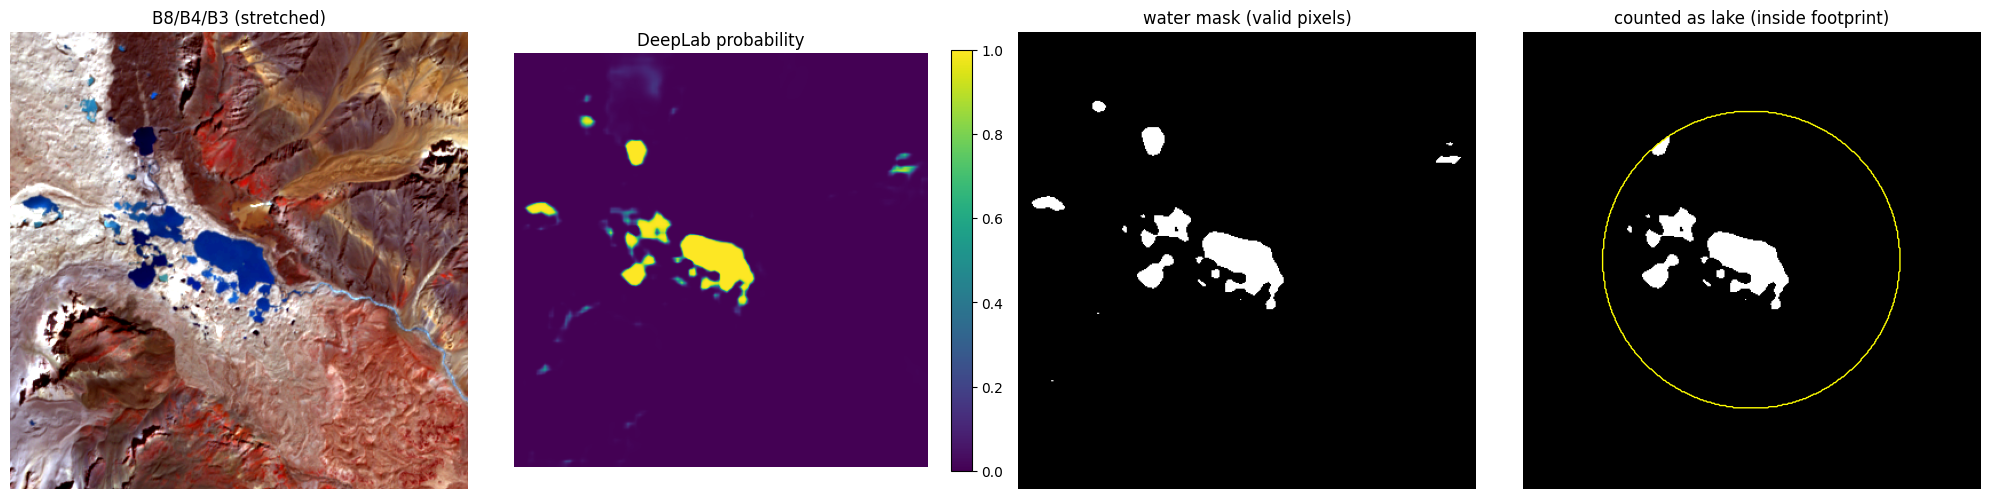

In [14]:
def smoke_test(lake_id="UK_GL_02", days=90, start=None, end=None):
    lake = next(l for l in lakes_active + SEEDS_ALL.to_dict("records") if l["lake_id"] == lake_id)
    t1 = utc(end) if end else utc(datetime.now(timezone.utc))
    t0 = utc(start) if start else t1 - pd.Timedelta(days=days)
    scenes = list_scenes(lake["lat"], lake["lon"], t0, t1)
    assert scenes, "no Sentinel-2 scenes found in window; increase `days`"
    for s in sorted(scenes, key=lambda s: s["cloud"])[:5]:          # first of the least-cloudy that is clear at the lake
        data, tr, crs = read_chip(download_chip(s["scene_id"], lake["lat"], lake["lon"]))
        m = measure_chip(lake, data, tr, crs)
        if m["footprint_valid_frac"] >= MIN_FOOTPRINT_VALID:
            break
    print(f"{lake['name']} | scene {s['scene_id']} | {s['time']:%Y-%m-%d} | scene cloud {s['cloud']:.0f}%")
    print(f"lake area in footprint: {m['lake_area_km2']:.4f} km² | clear pixels in footprint: {m['footprint_valid_frac']:.0%} "
          f"| CRS {crs} | chip {data.shape[2]}x{data.shape[1]} px")
    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(display_rgb(m["_img"])); ax[0].set_title("B8/B4/B3 (stretched)")
    im = ax[1].imshow(m["_prob"], vmin=0, vmax=1, cmap="viridis"); ax[1].set_title("DeepLab probability")
    plt.colorbar(im, ax=ax[1], fraction=0.046)
    ax[2].imshow(m["_water"], cmap="gray"); ax[2].set_title("water mask (valid pixels)")
    ax[3].imshow(m["_water"] & m["_fp"], cmap="gray"); ax[3].contour(m["_fp"], levels=[0.5], colors="yellow", linewidths=1)
    ax[3].set_title("counted as lake (inside footprint)")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    return m

_ = smoke_test("UK_GL_02")

**Pre/post-event check on South Lhonak.** Confirm the yellow footprint sits on the lake and the mask follows the shoreline, then see what the same footprint captures after the outburst. If the mask is wrong *before* the event, the area series means nothing.

South Lhonak Lake (GLOF Oct 2023) | scene 20230926T043709_20230926T045046_T45RXL | 2023-09-26 | scene cloud 49%
lake area in footprint: 0.7935 km² | clear pixels in footprint: 91% | CRS EPSG:32645 | chip 400x400 px


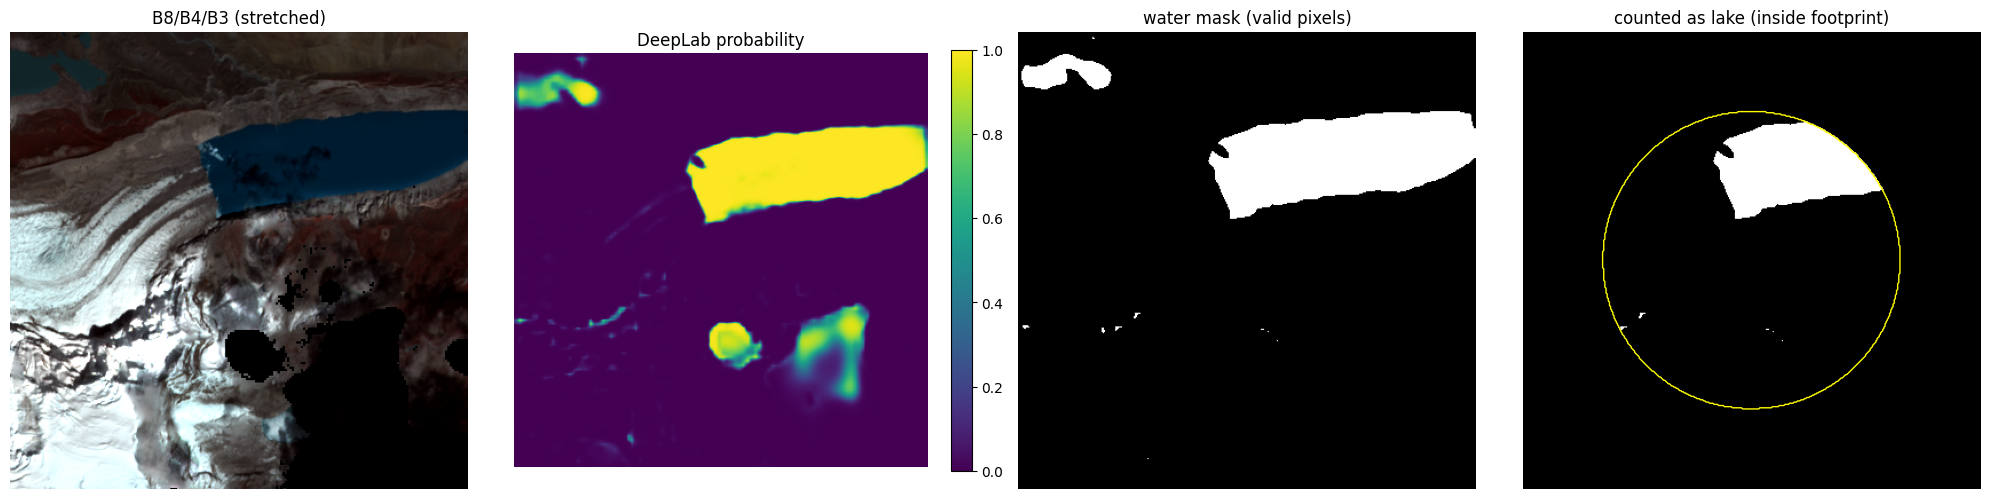

South Lhonak Lake (GLOF Oct 2023) | scene 20231024T044841_20231024T045715_T45RXL | 2023-10-24 | scene cloud 16%
lake area in footprint: 0.5772 km² | clear pixels in footprint: 100% | CRS EPSG:32645 | chip 400x400 px


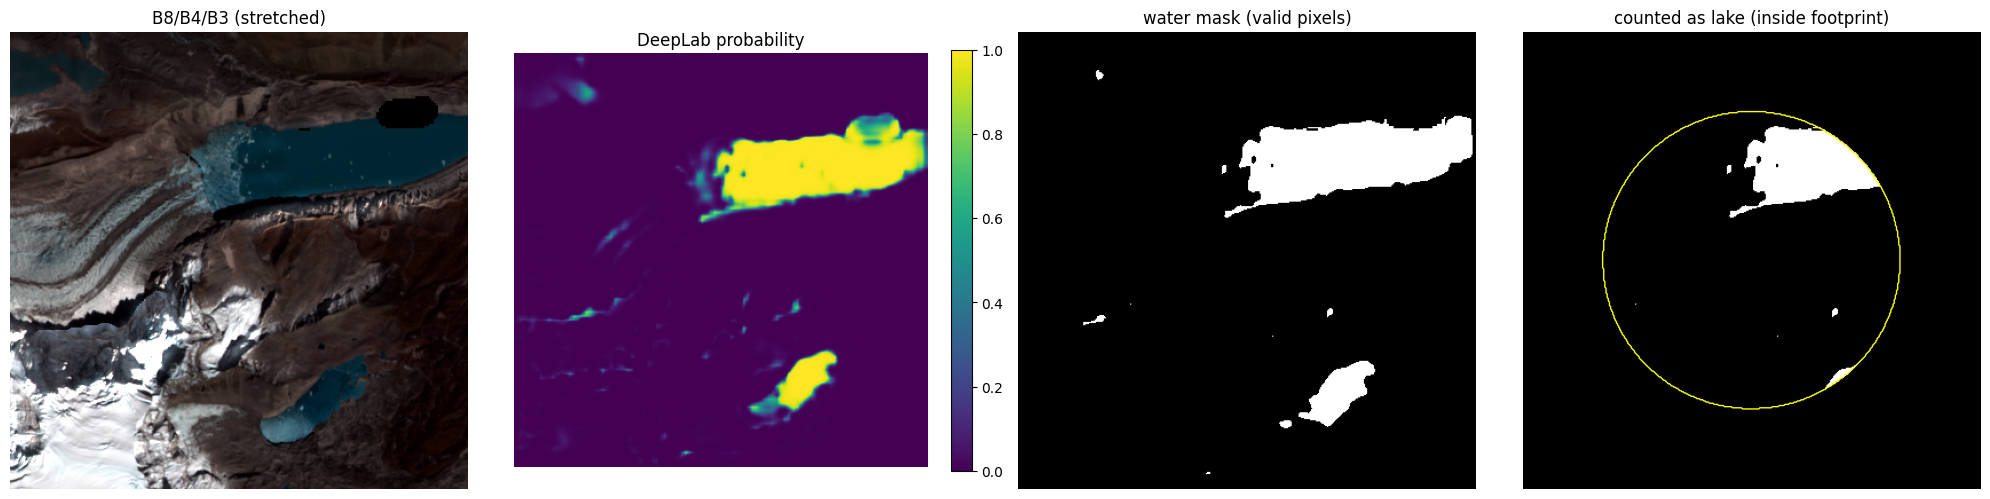

In [15]:
_ = smoke_test("SK_GL_01", start="2023-09-15", end="2023-10-03")   # before
_ = smoke_test("SK_GL_01", start="2023-10-06", end="2023-10-25")   # after

**11b · Replay a real outburst — South Lhonak Lake, 3–4 Oct 2023.**
This runs the *same* ingest + SAR + detection code with a simulated clock, stepping from before the event to after it, in a separate database. Weather/seismic context is skipped in replay (those APIs are forecast/real-time); optical and SAR are the signals under test.

What to look for: does the lake area fall after 4 Oct, did SAR agree, and how many days after the event does the level first leave GREEN? **If it doesn't fire, don't ship — tune `D` and `SAR_WATER_DB` until it does without crying wolf on the quiet lakes.**
Cloud may genuinely hide the lake for several days; that is a limitation to learn from, not a bug.

In [17]:
def plot_lake(lake_id):
    obs = q("SELECT * FROM observations WHERE lake_id=? ORDER BY scene_time", (lake_id,))
    asm = q("SELECT * FROM assessments WHERE lake_id=? ORDER BY id", (lake_id,))
    if obs.empty:
        print("no observations for", lake_id); return
    obs["t"] = pd.to_datetime(obs["scene_time"], utc=True)
    good, bad = obs[obs.reliable == 1], obs[obs.reliable == 0]

    sar = pd.DataFrame()
    if not asm.empty:
        rows = {}
        for x in asm.metrics_json:
            for r in (json.loads(x).get("sar_series") or []):
                rows[r["id"]] = r
        sar = pd.DataFrame(list(rows.values()))

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    a1.plot(good.t, good.lake_area_km2, "o-", color="tab:blue", label="optical, clear footprint")
    a1.plot(bad.t, bad.lake_area_km2, "x", color="lightgray", label="optical, cloudy (ignored)")
    a1.set_ylabel("optical km² in footprint"); a1.set_title(f"{lake_id}: optical (DeepLab)"); a1.grid(alpha=.3)

    a2.set_title("Sentinel-1 water area - each relative orbit is its own series (compared only with itself)")
    if not sar.empty:
        sar["t"] = pd.to_datetime(sar["t"], utc=True)
        for k, (orb, g) in enumerate(sar.sort_values("t").groupby("orbit")):
            a2.plot(g.t, g.water_km2, "s--", color=f"C{k+2}", alpha=.85, label=f"orbit {orb}")
        a2.legend(ncol=4, fontsize=8)
    a2.set_ylabel("SAR km² in footprint+buffer"); a2.grid(alpha=.3)

    for _, r in asm[asm.level != "GREEN"].iterrows():
        col = {"YELLOW": "gold", "ORANGE": "darkorange", "RED": "red"}[r.level]
        for a in (a1, a2):
            a.axvline(pd.to_datetime(r.assessed_at, utc=True), color=col, alpha=.5)
    plt.tight_layout(); plt.show()


def make_map(lakes=None, path=None):
    import folium
    lakes = lakes or lakes_active
    latest = q("""SELECT a.* FROM assessments a JOIN
                  (SELECT lake_id, MAX(id) mid FROM assessments GROUP BY lake_id) m ON a.id = m.mid""")
    latest = {r.lake_id: r for r in latest.itertuples()}
    colours = {"GREEN": "#2e7d32", "YELLOW": "#f9a825", "ORANGE": "#ef6c00", "RED": "#c62828", None: "#757575"}
    m = folium.Map(location=[np.mean([l["lat"] for l in lakes]), np.mean([l["lon"] for l in lakes])], zoom_start=7)
    folium.TileLayer("https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}", attr="Google", name="Satellite").add_to(m)
    for l in lakes:
        r = latest.get(l["lake_id"])
        lvl = r.level if r else None
        why = "<br>".join(json.loads(r.reasons_json)) if r else "no assessment yet"
        mt = json.loads(r.metrics_json) if r else {}
        area = mt.get("area_km2")
        html = (f"<b>{l['name']}</b><br>{lvl or 'n/a'} (score {r.score if r else '-'})<br>"
                f"area: {area:.3f} km²<br>" if area is not None else f"<b>{l['name']}</b><br>{lvl or 'n/a'}<br>") + why
        folium.CircleMarker([l["lat"], l["lon"]], radius=7, color=colours[lvl], fill=True, fill_opacity=.8,
                            popup=folium.Popup(html, max_width=380), tooltip=f"{l['name']} - {lvl}").add_to(m)
    folium.LayerControl().add_to(m)
    path = path or (BASE_DIR / "glof_status_map.html")
    m.save(str(path)); print("map saved:", path)
    return m


def export_features():
    """Flatten every assessment into a JEV-ready table (CSV + JSONL)."""
    asm = q("SELECT * FROM assessments ORDER BY assessed_at")
    rows = []
    for r in asm.itertuples():
        rows.append({"lake_id": r.lake_id, "assessed_at": r.assessed_at, "level": r.level, "score": r.score,
                     **json.loads(r.metrics_json)})
    df = pd.DataFrame(rows)
    df.to_csv(BASE_DIR / "jev_features.csv", index=False)
    df.to_json(BASE_DIR / "jev_features.jsonl", orient="records", lines=True)
    print(f"exported {len(df)} rows ->", BASE_DIR / "jev_features.csv")
    return df

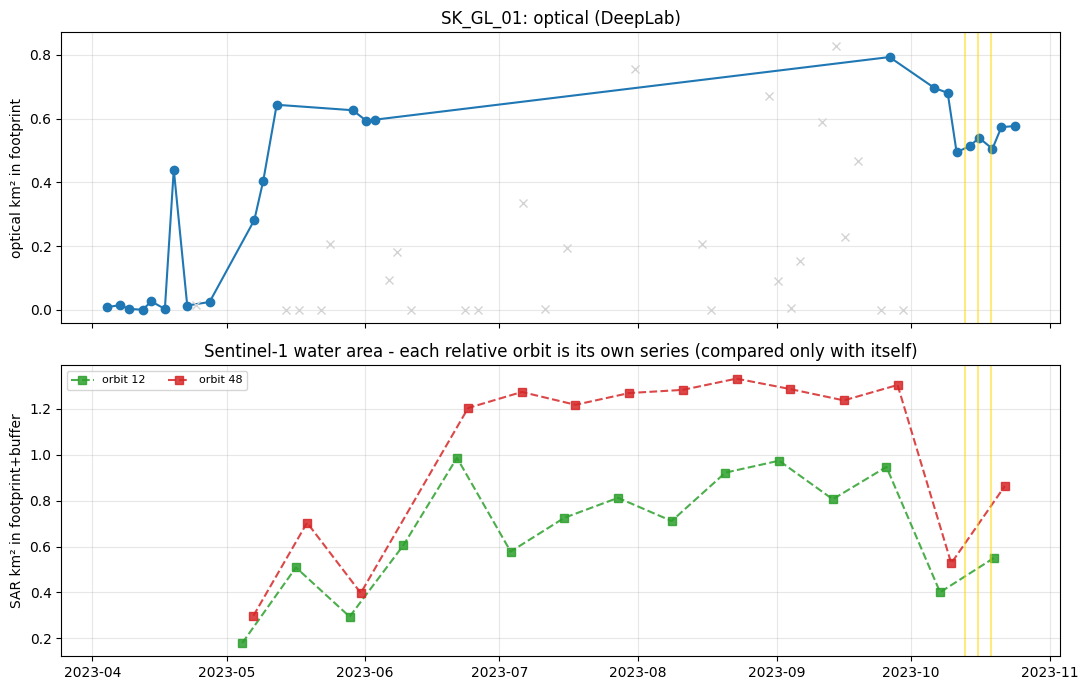

,assessed_at,level,score,reasons
0,2023-09-01T00:00:00+00:00,GREEN,0,
1,2023-09-04T00:00:00+00:00,GREEN,0,
2,2023-09-07T00:00:00+00:00,GREEN,0,
3,2023-09-16T00:00:00+00:00,GREEN,0,
4,2023-09-19T00:00:00+00:00,GREEN,0,
5,2023-09-28T00:00:00+00:00,GREEN,0,
6,2023-10-01T00:00:00+00:00,GREEN,0,
7,2023-10-07T00:00:00+00:00,GREEN,0,
8,2023-10-10T00:00:00+00:00,GREEN,0,
9,2023-10-13T00:00:00+00:00,YELLOW,2,SAR water area 59% below same-orbit baseline (...


In [18]:
def replay(lake_ids, start, end, step_days=3, db_name="replay.sqlite", plot=True, backfill_days=150):
    """backfill_days (history gathered before `start`, and the baseline window) is raised to 150 here:
    monsoon cloud leaves very few clear optical scenes, and a 2-3 point baseline is not trustworthy."""
    global DB_PATH, SAVE_QUICKLOOKS, BACKFILL_DAYS
    old_db, old_ql, old_bf, old_bl = DB_PATH, SAVE_QUICKLOOKS, BACKFILL_DAYS, D.BASELINE_DAYS
    DB_PATH, SAVE_QUICKLOOKS, BACKFILL_DAYS, D.BASELINE_DAYS = BASE_DIR / db_name, False, backfill_days, backfill_days
    try:
        if DB_PATH.exists():
            DB_PATH.unlink()
        init_db()
        lakes = SEEDS_ALL[SEEDS_ALL.lake_id.isin(lake_ids)].to_dict("records")
        t, end = utc(start), utc(end)
        while t <= end:
            ingest_cycle(lakes, t, verbose=False)
            assess_cycle(lakes, t, with_context=False, send_notifications=False)
            t += pd.Timedelta(days=step_days)
        out = q("SELECT lake_id, assessed_at, level, score, reasons_json, metrics_json FROM assessments ORDER BY id")
        if plot:
            for lid in lake_ids:
                plot_lake(lid)
        return out
    finally:
        DB_PATH, SAVE_QUICKLOOKS, BACKFILL_DAYS, D.BASELINE_DAYS = old_db, old_ql, old_bf, old_bl

# Baseline from ~150 d before the first step. Run once; takes several minutes.
replay_df = replay(["SK_GL_01"], start="2023-09-01", end="2023-10-25", step_days=3)
replay_df["reasons"] = replay_df["reasons_json"].map(lambda s: " | ".join(json.loads(s)))
replay_df[["assessed_at", "level", "score", "reasons"]]

**11c · False-alarm test on the 13 Uttarakhand lakes.**
One detected event proves little: any detector can catch one event if it fires often enough. This replays the same dates over the Uttarakhand lakes, where no outburst is assumed in this window, and counts how often each one leaves GREEN. Treat those counts as an *upper bound* on false alarms, and open `plot_lake()` / quicklooks for any flagged lake to confirm it is not a real change.
Pass `event_date` to also get the detection delay for a positive control.

In [19]:
LEVEL_RANK = {l: i for i, l in enumerate(LEVELS)}

def replay_report(lake_ids, start, end, step_days=3, event_date=None, db_name="replay_report.sqlite"):
    """Replay, then summarise per lake: how often it flagged, at what level, and (optionally) detection delay."""
    df = replay(lake_ids, start, end, step_days=step_days, db_name=db_name, plot=False)
    if df.empty:
        print("no assessments produced"); return df, pd.DataFrame()
    df["t"] = pd.to_datetime(df["assessed_at"], utc=True)
    df["rank"] = df["level"].map(LEVEL_RANK)
    ev = utc(event_date) if event_date else None
    rows = []
    for lid, g in df.groupby("lake_id"):
        pre = g if ev is None else g[g.t < ev]
        post = pd.DataFrame() if ev is None else g[g.t >= ev]
        flagged = pre[pre["rank"] >= 1]
        row = {"lake_id": lid, "assessments": len(pre),
               "yellow+": int((pre["rank"] >= 1).sum()), "orange+": int((pre["rank"] >= 2).sum()),
               "max_level": LEVELS[int(pre["rank"].max())] if len(pre) else "-",
               "first_flag": flagged["t"].min().date() if len(flagged) else None}
        if ev is not None:
            hit = post[post["rank"] >= 1]
            hit2 = post[post["rank"] >= 2]
            row["first_yellow_after_event_d"] = (hit["t"].min() - ev).days if len(hit) else None
            row["first_orange_after_event_d"] = (hit2["t"].min() - ev).days if len(hit2) else None
        rows.append(row)
    rep = pd.DataFrame(rows)
    n = int(rep["assessments"].sum())
    print(f"\nAssessments (pre-event if event_date given): {n} | "
          f"YELLOW+ rate {rep['yellow+'].sum() / max(n, 1):.1%} | ORANGE+ rate {rep['orange+'].sum() / max(n, 1):.1%}")
    return df, rep

UK_IDS = [s[0] for s in SEED_LAKES if s[0].startswith("UK_")]

# Quiet-lake false-alarm check (no known event assumed here)
uk_df, uk_report = replay_report(UK_IDS, start="2023-09-01", end="2023-10-25")
uk_report

[GLOF ORANGE] Unnamed Lake 1 (31.1512N, 79.2673E) score 5: Optical drawdown: 0.000 km² is 100% below the 9-scene baseline (0.054 km², z=-7.7) | Near-complete drawdown (≥ 60%)
[GLOF ORANGE] Masar Tal (Bhilangna Lake) (30.7425N, 78.9877E) score 5: Optical drawdown: 0.100 km² is 72% below the 12-scene baseline (0.362 km², z=-3.1) | Near-complete drawdown (≥ 60%)
[GLOF ORANGE] Unnamed Lake 1 (31.1512N, 79.2673E) score 5: Optical drawdown: 0.000 km² is 100% below the 9-scene baseline (0.054 km², z=-7.7) | Near-complete drawdown (≥ 60%)
[GLOF ORANGE] Masar Tal (Bhilangna Lake) (30.7425N, 78.9877E) score 5: Optical drawdown: 0.100 km² is 72% below the 12-scene baseline (0.362 km², z=-3.1) | Near-complete drawdown (≥ 60%)
[GLOF ORANGE] Unnamed Lake 1 (31.1512N, 79.2673E) score 5: Optical drawdown: 0.000 km² is 100% below the 9-scene baseline (0.054 km², z=-7.7) | Near-complete drawdown (≥ 60%)

Assessments (pre-event if event_date given): 193 | YELLOW+ rate 7.8% | ORANGE+ rate 2.6%


,lake_id,assessments,yellow+,orange+,max_level,first_flag
0,UK_GL_01,18,1,0,YELLOW,2023-09-28
1,UK_GL_02,17,0,0,GREEN,None
2,UK_GL_03,14,0,0,GREEN,None
3,UK_GL_04,13,0,0,GREEN,None
4,UK_GL_05,16,2,2,ORANGE,2023-10-22
5,UK_GL_06,14,6,0,YELLOW,2023-09-04
6,UK_GL_07,14,0,0,GREEN,None
7,UK_GL_08,15,6,3,ORANGE,2023-09-16
8,UK_GL_09,14,0,0,GREEN,None
9,UK_GL_10,14,0,0,GREEN,None


In [20]:
# Positive control: how many days after 4 Oct 2023 does South Lhonak first leave GREEN / reach ORANGE?
sk_df, sk_report = replay_report(["SK_GL_01"], start="2023-09-01", end="2023-10-25", event_date="2023-10-04")
sk_report


Assessments (pre-event if event_date given): 7 | YELLOW+ rate 0.0% | ORANGE+ rate 0.0%


,lake_id,assessments,yellow+,orange+,max_level,first_flag,first_yellow_after_event_d,first_orange_after_event_d
0,SK_GL_01,7,0,0,GREEN,None,9,None


## 12 · Go live
1. Run the **first cycle** (back-fills history; may take a while and may need a second call if the download budget is reached).
2. Check `Levels:` and the map/plots below.
3. Start the loop.

**Colab runtimes die when idle.** For genuine 24×7 operation, export this notebook to a `.py` file and run `run_cycle()` from cron / GitHub Actions / Cloud Run Jobs every `POLL_HOURS`. State is entirely in SQLite + the registry CSV, so cycles are resumable and idempotent.

In [21]:
# 1) Drain the history back-fill first (resumable: safe to interrupt and re-run).
#    ~90 days x (#lakes) Sentinel-2 chips; DOWNLOAD_BUDGET limits each pass.
while True:
    stats = ingest_cycle(lakes_active, datetime.now(timezone.utc))
    if stats["backlog"] == 0:
        break

# 2) Full cycle: SAR + weather + GPM + seismic + assessment + alerts.
stats, results = run_cycle()
stats

Ingest: 0 lake-scenes to process this cycle (0 left in backlog)

=== cycle @ 2026-10-05 16:45 UTC | 164 lakes ===
Ingest: 0 lake-scenes to process this cycle (0 left in backlog)
Levels: {'GREEN': np.int64(152), 'YELLOW': np.int64(9), 'ORANGE': np.int64(3), 'RED': np.int64(0)}
  YELLOW Mabang Tal (Surya Sarovar): Rapid expansion: +163% in 10 d (z=7.3) | SAR water area +318% above same-orbit baseline (z=31.8, orbit 165, 2026-09-27)
  ORANGE Syantyankti Lake: Optical drawdown: 0.051 km² is 67% below the 3-scene baseline (0.155 km², z=-3.5) | Near-complete drawdown (≥ 60%)
  YELLOW Saraswati Tal: Rapid expansion: +71% in 10 d (z=12.6)
  YELLOW Sikkim_East_Nepal lake b6da: Rapid expansion: +275% in 3 d (z=4.8)
  YELLOW Uttarakhand lake 4751: SAR water area 43% below same-orbit baseline (z=-3.2, orbit 165, 2026-09-27) | CAUTION: sub-zero temperatures - an apparent drawdown may be lake ice / snow, not drainage
  YELLOW Uttarakhand lake 83b3: Rapid expansion: +1512% in 10 d (z=20.3) | CAUTION:

{'processed': 0, 'reliable': 0, 'backlog': 0}

In [22]:
RUN_FOREVER = False          # set True only after the first cycle looks right

if RUN_FOREVER:
    while True:
        try:
            run_cycle()
        except KeyboardInterrupt:
            print("Stopped."); break
        except Exception as exc:
            print("Cycle error:", repr(exc))
        print(f"Sleeping {POLL_HOURS} h ...")
        time.sleep(POLL_HOURS * 3600)

## 13 · Dashboard, per-lake plots, and JEV export

In [23]:
# def plot_lake(lake_id):
#     obs = q("SELECT * FROM observations WHERE lake_id=? ORDER BY scene_time", (lake_id,))
#     asm = q("SELECT * FROM assessments WHERE lake_id=? ORDER BY id", (lake_id,))
#     if obs.empty:
#         print("no observations for", lake_id); return
#     obs["t"] = pd.to_datetime(obs["scene_time"], utc=True)
#     good, bad = obs[obs.reliable == 1], obs[obs.reliable == 0]

#     sar = pd.DataFrame()
#     if not asm.empty:
#         rows = {}
#         for x in asm.metrics_json:
#             for r in (json.loads(x).get("sar_series") or []):
#                 rows[r["id"]] = r
#         sar = pd.DataFrame(list(rows.values()))

#     fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
#     a1.plot(good.t, good.lake_area_km2, "o-", color="tab:blue", label="optical, clear footprint")
#     a1.plot(bad.t, bad.lake_area_km2, "x", color="lightgray", label="optical, cloudy (ignored)")
#     a1.set_ylabel("optical km² in footprint"); a1.set_title(f"{lake_id}: optical (DeepLab)"); a1.grid(alpha=.3)

#     a2.set_title("Sentinel-1 water area - each relative orbit is its own series (compared only with itself)")
#     if not sar.empty:
#         sar["t"] = pd.to_datetime(sar["t"], utc=True)
#         for k, (orb, g) in enumerate(sar.sort_values("t").groupby("orbit")):
#             a2.plot(g.t, g.water_km2, "s--", color=f"C{k+2}", alpha=.85, label=f"orbit {orb}")
#         a2.legend(ncol=4, fontsize=8)
#     a2.set_ylabel("SAR km² in footprint+buffer"); a2.grid(alpha=.3)

#     for _, r in asm[asm.level != "GREEN"].iterrows():
#         col = {"YELLOW": "gold", "ORANGE": "darkorange", "RED": "red"}[r.level]
#         for a in (a1, a2):
#             a.axvline(pd.to_datetime(r.assessed_at, utc=True), color=col, alpha=.5)
#     plt.tight_layout(); plt.show()


# def make_map(lakes=None, path=None):
#     import folium
#     lakes = lakes or lakes_active
#     latest = q("""SELECT a.* FROM assessments a JOIN
#                   (SELECT lake_id, MAX(id) mid FROM assessments GROUP BY lake_id) m ON a.id = m.mid""")
#     latest = {r.lake_id: r for r in latest.itertuples()}
#     colours = {"GREEN": "#2e7d32", "YELLOW": "#f9a825", "ORANGE": "#ef6c00", "RED": "#c62828", None: "#757575"}
#     m = folium.Map(location=[np.mean([l["lat"] for l in lakes]), np.mean([l["lon"] for l in lakes])], zoom_start=7)
#     folium.TileLayer("https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}", attr="Google", name="Satellite").add_to(m)
#     for l in lakes:
#         r = latest.get(l["lake_id"])
#         lvl = r.level if r else None
#         why = "<br>".join(json.loads(r.reasons_json)) if r else "no assessment yet"
#         mt = json.loads(r.metrics_json) if r else {}
#         area = mt.get("area_km2")
#         html = (f"<b>{l['name']}</b><br>{lvl or 'n/a'} (score {r.score if r else '-'})<br>"
#                 f"area: {area:.3f} km²<br>" if area is not None else f"<b>{l['name']}</b><br>{lvl or 'n/a'}<br>") + why
#         folium.CircleMarker([l["lat"], l["lon"]], radius=7, color=colours[lvl], fill=True, fill_opacity=.8,
#                             popup=folium.Popup(html, max_width=380), tooltip=f"{l['name']} - {lvl}").add_to(m)
#     folium.LayerControl().add_to(m)
#     path = path or (BASE_DIR / "glof_status_map.html")
#     m.save(str(path)); print("map saved:", path)
#     return m


# def export_features():
#     """Flatten every assessment into a JEV-ready table (CSV + JSONL)."""
#     asm = q("SELECT * FROM assessments ORDER BY assessed_at")
#     rows = []
#     for r in asm.itertuples():
#         rows.append({"lake_id": r.lake_id, "assessed_at": r.assessed_at, "level": r.level, "score": r.score,
#                      **json.loads(r.metrics_json)})
#     df = pd.DataFrame(rows)
#     df.to_csv(BASE_DIR / "jev_features.csv", index=False)
#     df.to_json(BASE_DIR / "jev_features.jsonl", orient="records", lines=True)
#     print(f"exported {len(df)} rows ->", BASE_DIR / "jev_features.csv")
#     return df

make_map()

map saved: /content/drive/MyDrive/glof_monitor/glof_status_map.html


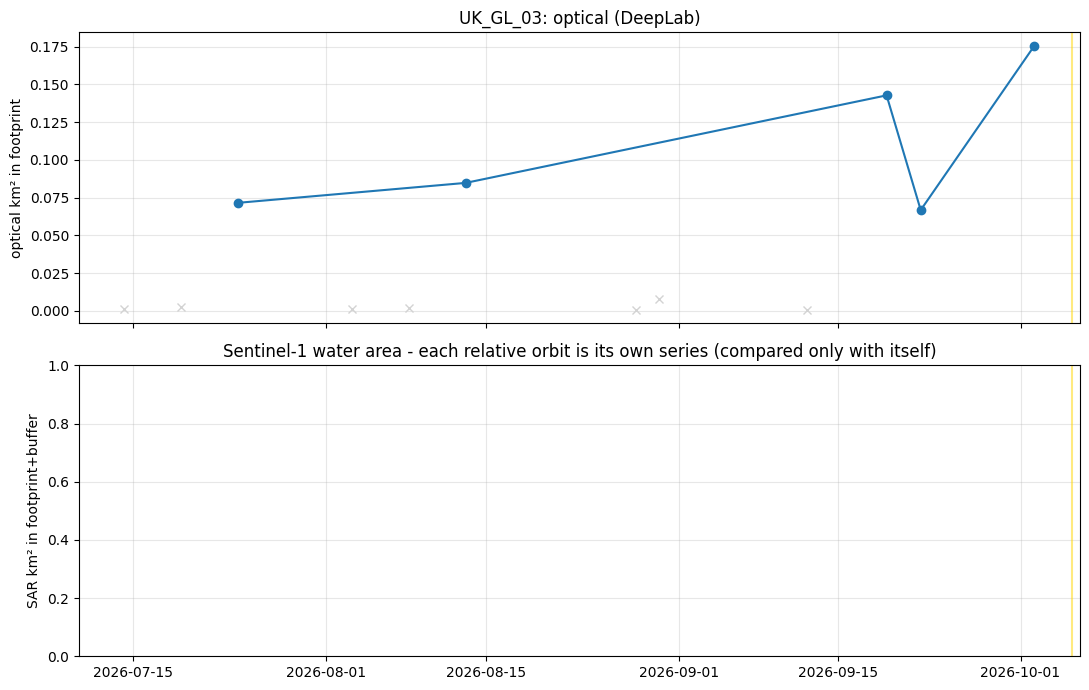

exported 183 rows -> /content/drive/MyDrive/glof_monitor/jev_features.csv


,lake_id,assessed_at,level,score,optical_scene,optical_time,area_km2,footprint_valid_frac,chip_water_km2,n_history,...,eq_n_24h,eq_n_72h,eq_max_mag_24h,eq_max_mag_near_72h,eq_nearest_km_24h,possible_ice_cover,sar_sigma_km2,sar_z,sar_orbit,sar_series
178,HKH_48ff169b,2026-10-05T16:45:11.553901+00:00,YELLOW,2,20261002T051649_20261002T052420_T44RLV,2026-10-02T05:30:17.253000+00:00,0.8306,1.0,1.0350,5.0,...,0,0,None,None,None,True,0.049338,-0.728979,129.0,[{'id': 'S1A_IW_GRDH_1SDV_20260608T123941_2026...
179,HKH_aba75d32,2026-10-05T16:45:11.553901+00:00,YELLOW,2,20261004T050651_20261004T051540_T44RNV,2026-10-04T05:20:16.221000+00:00,0.1909,1.0,0.2395,5.0,...,0,0,None,None,None,True,0.296498,-0.600760,165.0,[{'id': 'S1A_IW_GRDH_1SDV_20260608T123916_2026...
180,HKH_66657338,2026-10-05T16:45:11.553901+00:00,GREEN,0,20261005T052659_20261005T053448_T44RKV,2026-10-05T05:40:16.847000+00:00,0.3197,1.0,0.7924,4.0,...,0,0,None,None,None,NaN,0.318015,-1.744522,129.0,[{'id': 'S1A_IW_GRDH_1SDV_20260609T004317_2026...
181,HKH_d2d4b60a,2026-10-05T16:45:11.553901+00:00,GREEN,0,20261004T050651_20261004T051540_T44RNV,2026-10-04T05:20:16.221000+00:00,0.0000,1.0,0.0026,5.0,...,0,0,None,None,None,True,0.095000,-1.216763,165.0,[{'id': 'S1A_IW_GRDH_1SDV_20260608T123941_2026...
182,HKH_210a0f4f,2026-10-05T16:45:11.553901+00:00,GREEN,0,20261003T044659_20261003T045516_T45RWL,2026-10-03T05:01:00.674000+00:00,0.2269,1.0,0.2654,1.0,...,0,0,None,None,None,NaN,0.174020,-2.984702,48.0,[{'id': 'S1A_IW_GRDH_1SDV_20260608T000303_2026...


In [24]:
# Time series for any lake, e.g. the most recently flagged one (or pick an id from `registry`)
flagged = [l["lake_id"] for l, r in results if r["level"] != "GREEN"]
plot_lake(flagged[0] if flagged else lakes_active[0]["lake_id"])
features = export_features()
features.tail()

## What to do next (in order of value)
1. **Calibrate on more known events** (e.g. Sikkim 2023, Chamoli/Dhauliganga, 2013 Kedarnath-era lakes via Landsat, Nepal 2024 Thame) and tune `D`. Use quiet lakes to measure the false-alarm rate.
2. **Fine-tune DeepLab on single-date scenes** if the smoke test shows noise — it was trained/validated on seasonal composites.
3. **Add a lake-ice mask** (e.g. NDSI / temperature gating) — freeze-up is the biggest source of false "drawdown".
4. **Downstream gauges / in-lake sensors** for minute-scale warning; satellites only give days.
5. **Train the JEV model** on `jev_features.csv` with labelled event / non-event windows (1 h, 6 h, 24 h, 72 h horizons).